# Dự đoán Ung thư Vú (Breast Cancer Prediction)

**Mục tiêu dự án:** Xây dựng mô hình Machine Learning dự đoán tính chất khối u là **Ác tính (M - Malignant)** hay **Lành tính (B - Benign)** dựa trên các thông số đặc trưng của tế bào sinh thiết.

**Quy trình thực hiện:** 
1. **Khám phá dữ liệu (EDA):** Tìm hiểu phân phối dữ liệu, phát hiện ngoại lai và đánh giá mức độ tương quan cơ bản.
2. **Tiền xử lý (Data Preprocessing):** Chuẩn hóa dữ liệu (Scaling) và lựa chọn đặc trưng (Feature Selection) khắc phục hiện tượng đa cộng tuyến.
3. **Mô hình Baseline**: Sử dụng Logistic Regression và Decision Tree Classifier từ thư viện `scikit-learn` để làm chuẩn so sánh.
4. **Thuật toán Tự xây dựng**: Cài đặt thủ công thuật toán Cây quyết định (CART) và Grid Search để hiểu sâu về cơ chế hoạt động.
5. **Tối ưu hoá bằng** Random forest classifier
6. **Đánh giá mô hình (Evaluation):** So sánh hiệu suất giữa các mô hình dựa trên Accuracy, Recall, f1-score và Confusion Matrix.

## Import 1 số thư viện cần thiết và lấy dữ liệu

In [110]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [111]:
df = pd.read_csv('../datasets/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# 1. Khám phá dữ liệu (Exploratory Data Analysis - EDA)
Trong phần này, chúng ta sẽ thực hiện 2 việc chính:
1. Loại bỏ các thuộc tính không mang ý nghĩa dự đoán như cột ID hay các cột dữ liệu trống.
2. Trực quan hóa dữ liệu để xem sự phân bố của các biến và mã hóa nhãn dự đoán (`diagnosis`).

In [112]:
df.diagnosis.unique()

array(['M', 'B'], dtype=object)

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [114]:
df.drop('id', axis=1, inplace=True)
df.drop("Unnamed: 32", axis=1, inplace=True)

In [115]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [116]:
# Supervised-> target
# Unsupervised
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [117]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [118]:
df['diagnosis'] = df['diagnosis'].apply(lambda val:1 if val=='M' else 0)

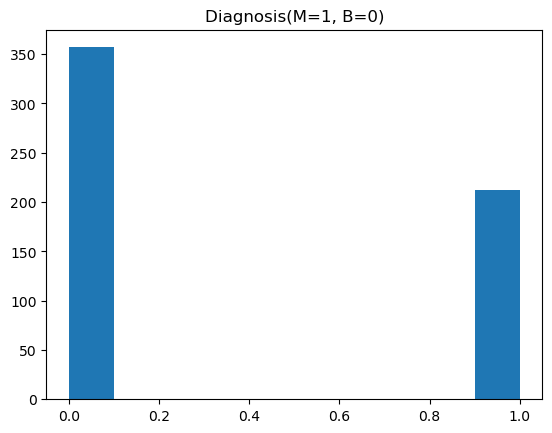

In [119]:
plt.hist(df['diagnosis'])
plt.title('Diagnosis(M=1, B=0)')
plt.show()

### Vẽ biểu đồ Boxplot để kiểm tra ngoại lai (Outliers)
Boxplot giúp chúng ta nhìn rõ sự phân bố của dữ liệu và phát hiện các điểm ngoại lai (outliers) có thể ảnh hưởng đến mô hình.

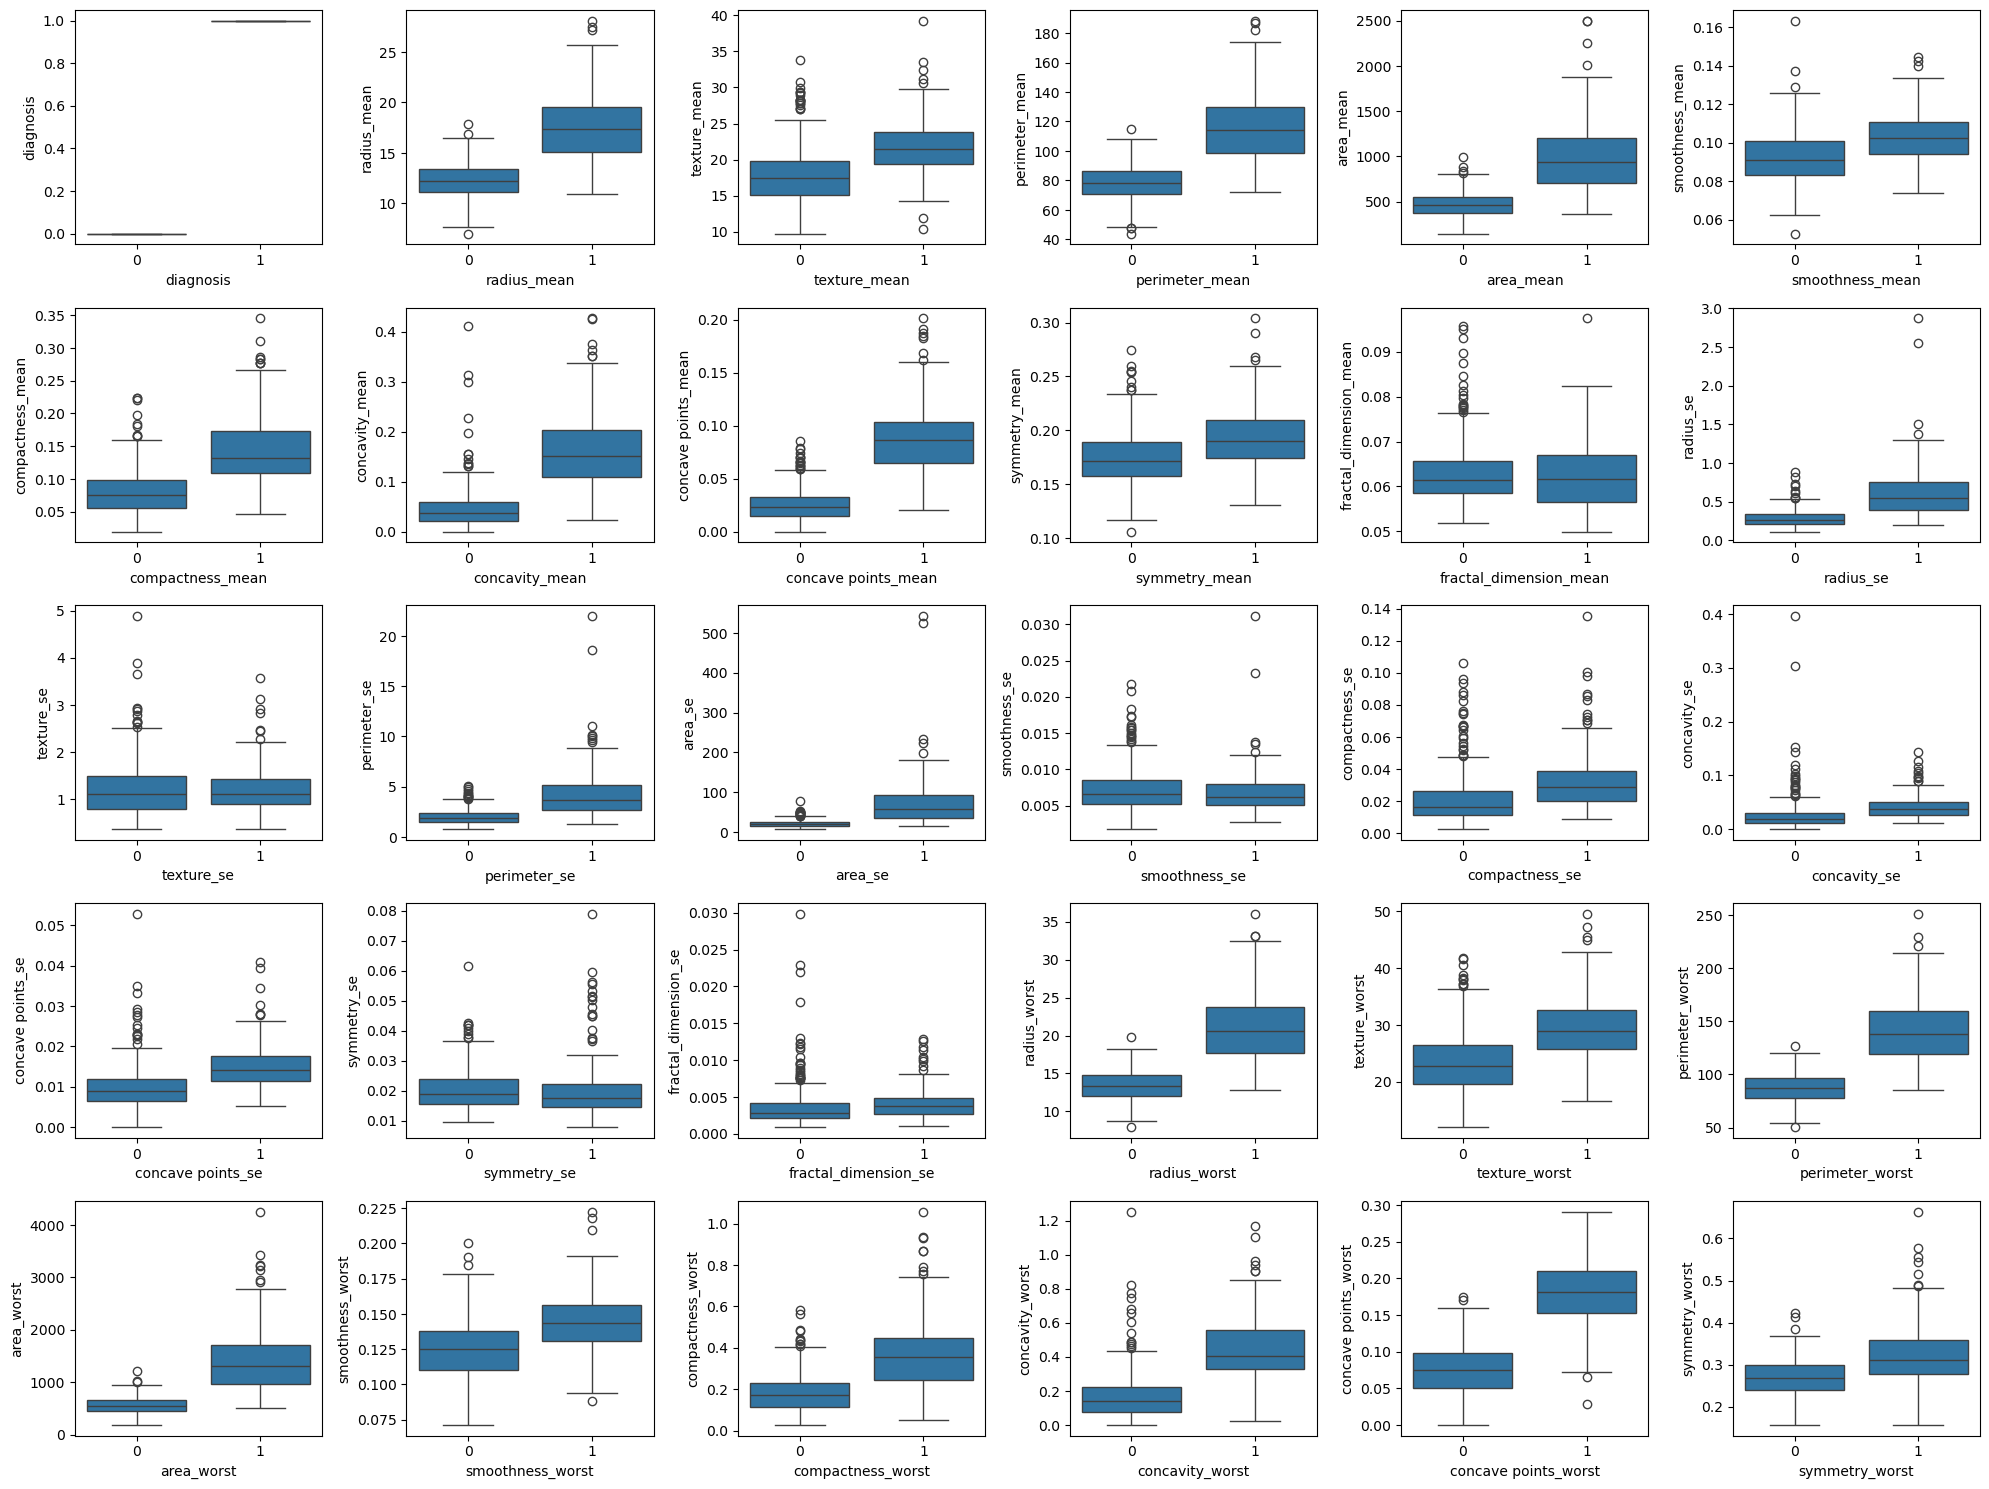

In [120]:
plt.figure(figsize=(20,15))
plotnumber=1
for column in df:
    if plotnumber<=30:
        ax = plt.subplot(5,6, plotnumber)
        sns.boxplot(x='diagnosis', y=column, data=df)
        plt.xlabel(column)
    plotnumber+=1

plt.tight_layout()
plt.show()

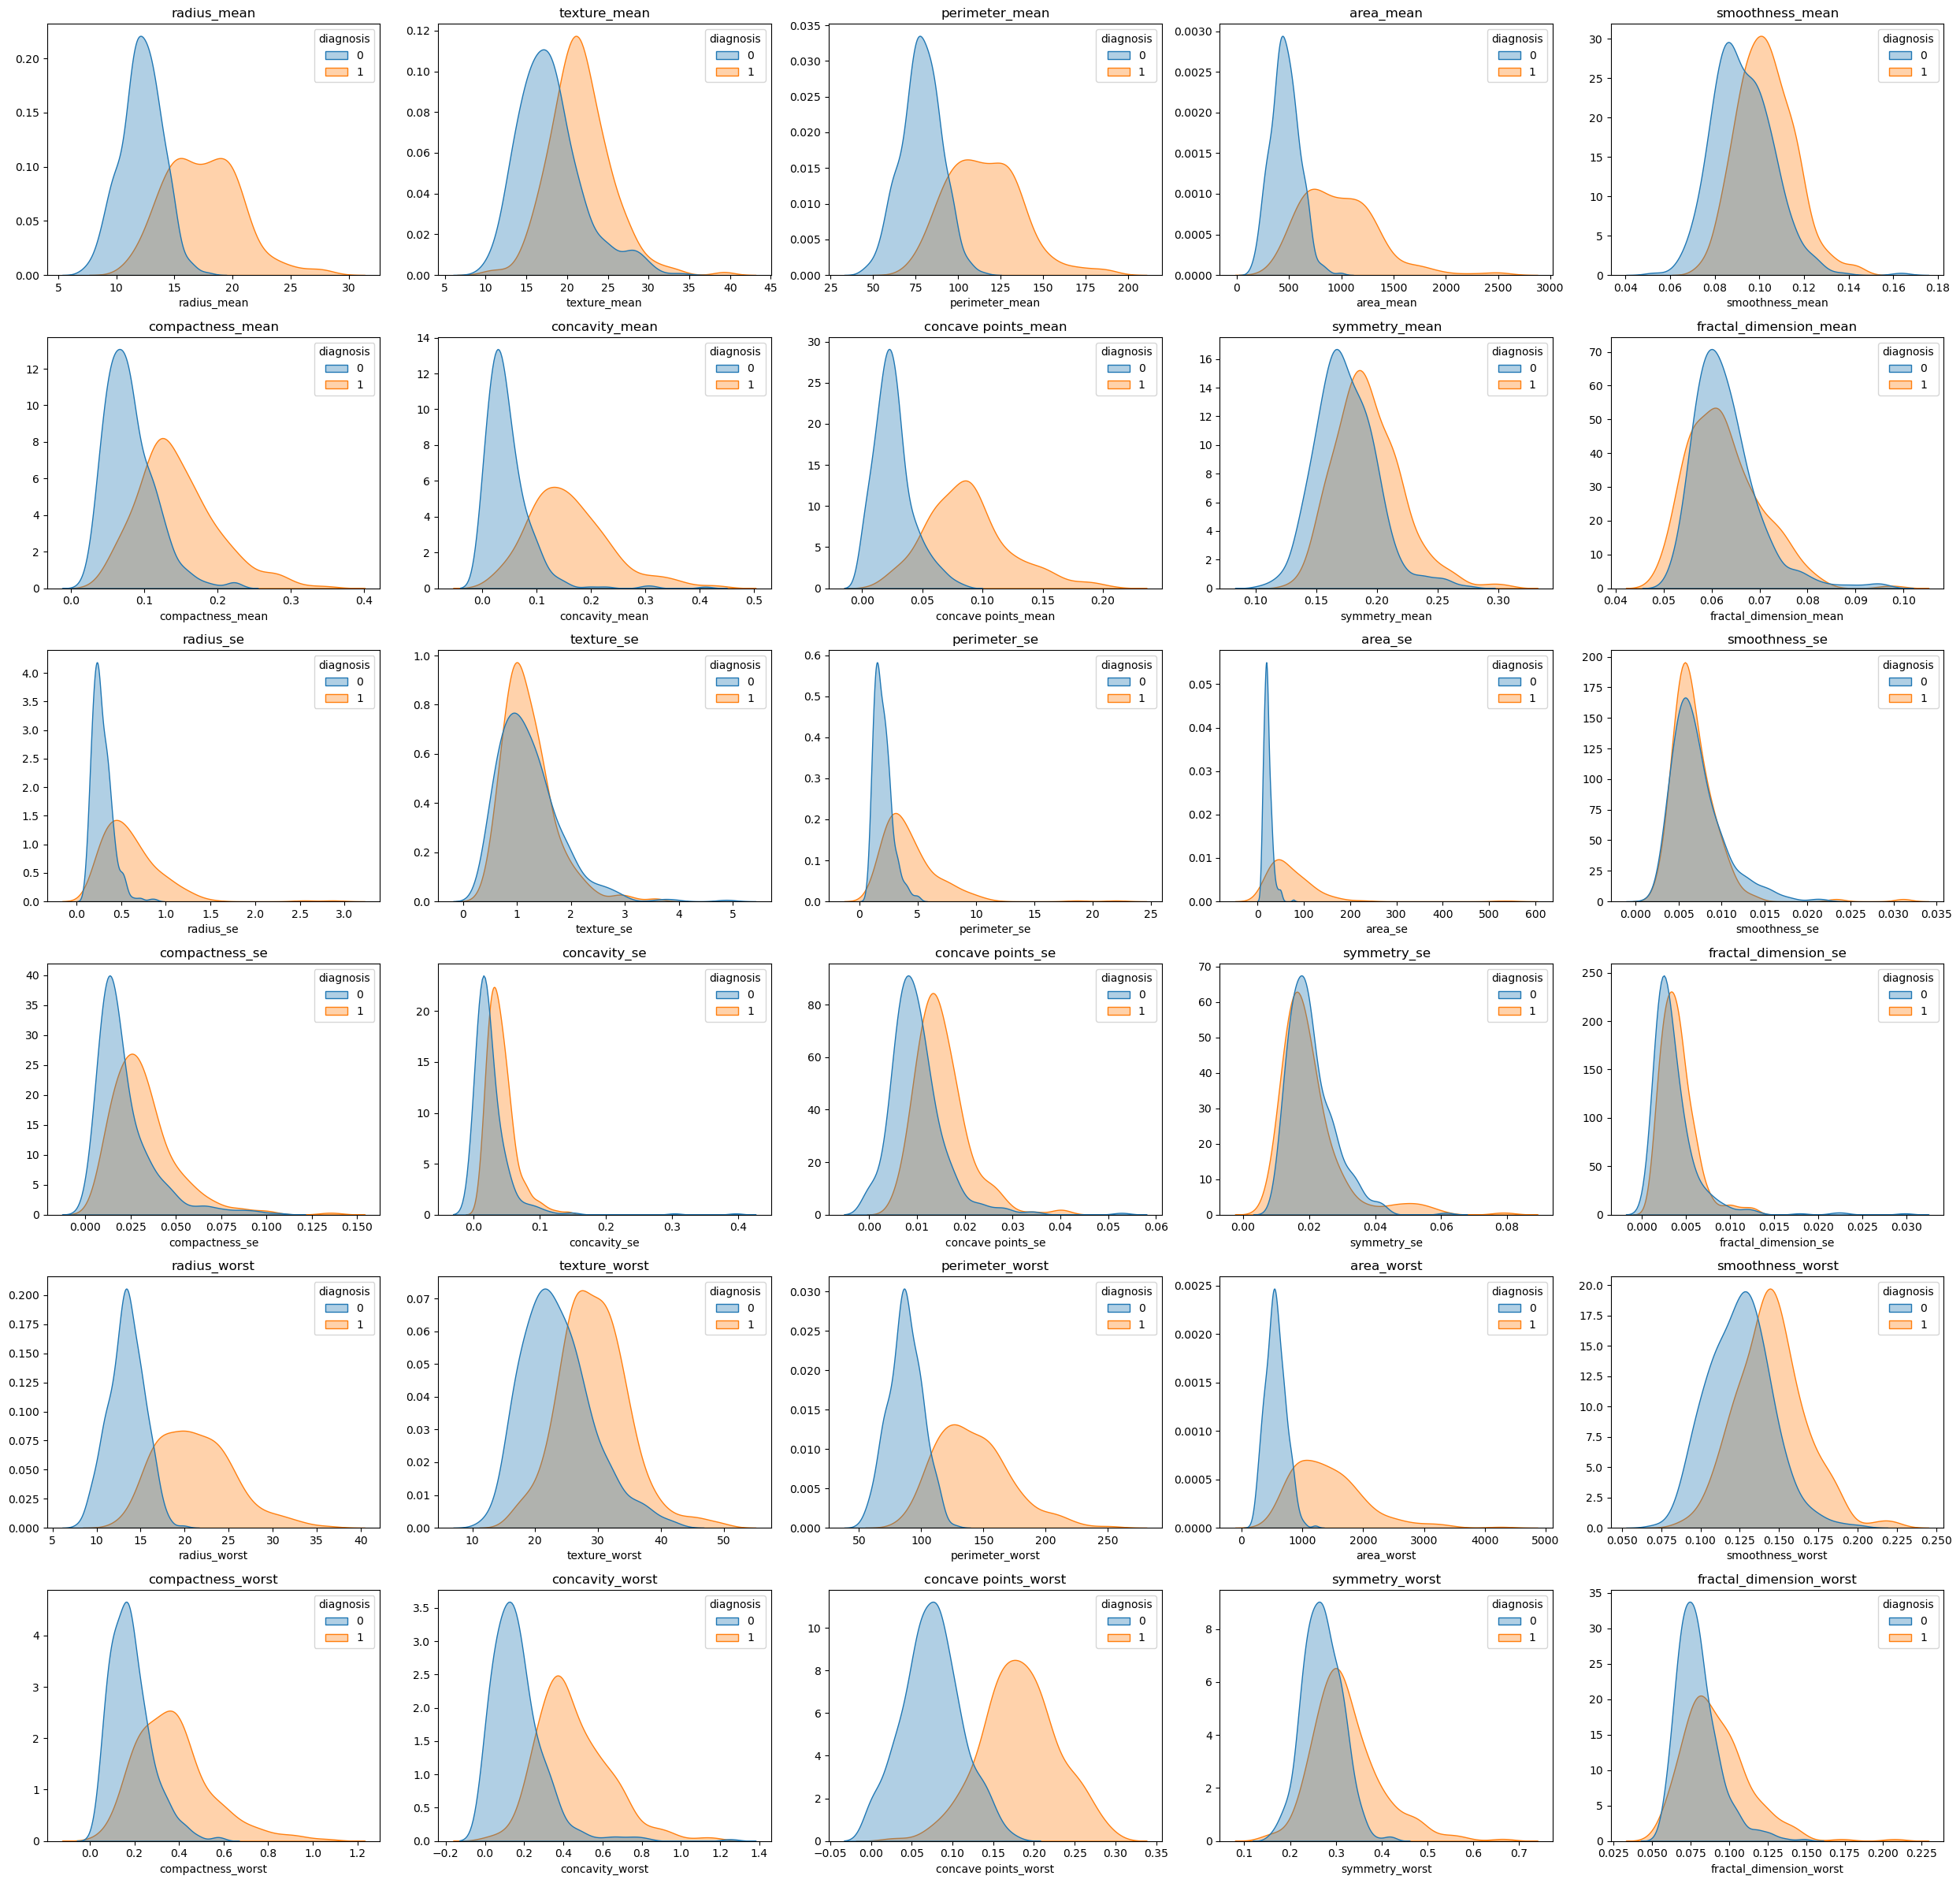

In [121]:
# Feature distribution by diagnosis (0=Benign, 1=Malignant)
feature_cols = [col for col in df.columns if col != 'diagnosis']

n_cols = 5
n_rows = int(np.ceil(len(feature_cols) / n_cols))
plt.figure(figsize=(5 * n_cols, 4 * n_rows))
for i, col in enumerate(feature_cols, start=1):
    ax = plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(data=df, x=col, hue='diagnosis', fill=True, common_norm=False, alpha=0.35, ax=ax)
    ax.set_title(col)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [122]:
df.corr()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


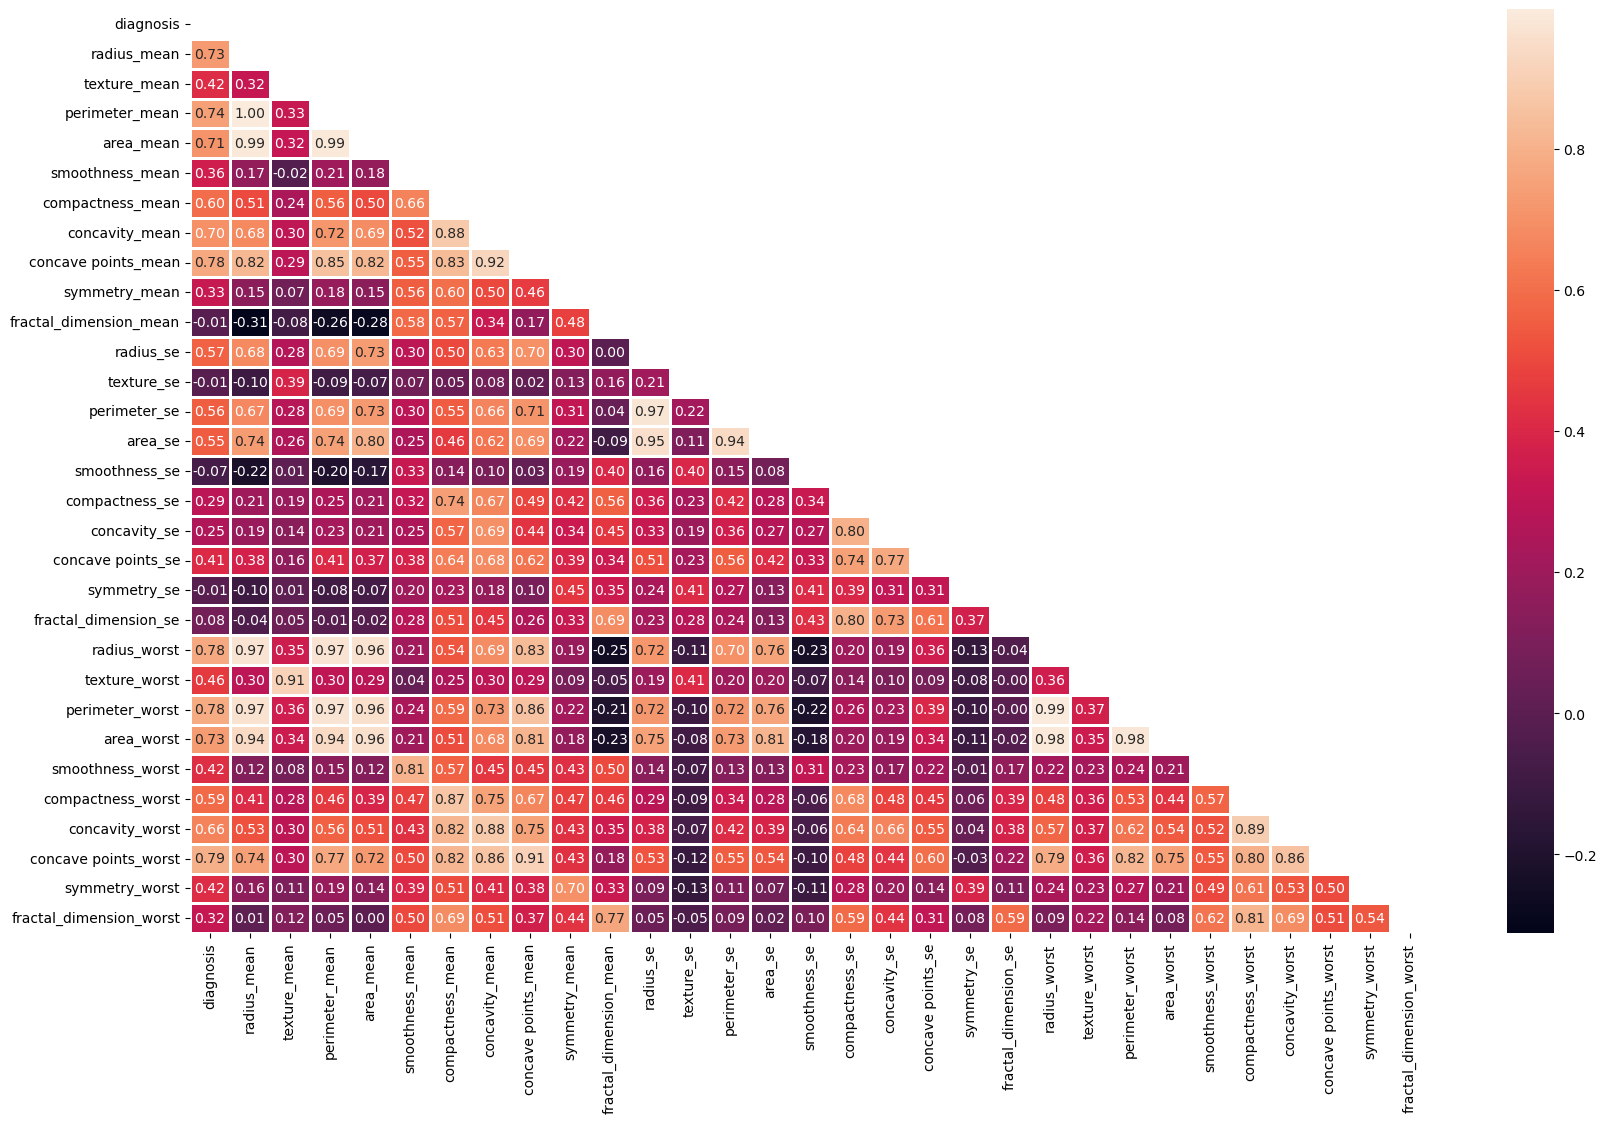

In [123]:
# heatmap
plt.figure(figsize=(20,12))
corr=df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, linewidths=1, annot=True, fmt = ".2f")
plt.show()

### Điểm lưu ý về Hiện tượng Đa cộng tuyến (Multicollinearity)
Dựa vào ma trận Heatmap ở trên, chúng ta có thể thấy nhiều nhóm đặc trưng có **độ tương quan rất cao** với nhau (VD: `radius_mean`, `perimeter_mean`, `area_mean`...).
Nếu giữ lại toàn bộ, mô hình sẽ bị nhiễu và việc tính toán trở nên cồng kềnh. Do đó, ở bước tiếp theo chúng ta sẽ tiến hành loại bỏ các cột có tương quan quá lớn (> 0.92).

# 2. Data preprocessing

### Xử lý dữ liệu đa cộng tuyến

In [124]:
# feature selection
corr_matrix = df.corr().abs()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
tri_df = corr_matrix.mask(mask)

to_drop = [x for x in tri_df.columns if any(tri_df[x]>0.92)]

df = df.drop(to_drop, axis=1)

print(df.shape[1])

23


In [125]:
df.head()

,diagnosis,texture_mean,smoothness_mean,compactness_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,texture_se,area_se,smoothness_se,...,symmetry_se,fractal_dimension_se,texture_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,10.38,0.11840,0.27760,0.14710,0.2419,0.07871,0.9053,153.40,0.006399,...,0.03003,0.006193,17.33,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,17.77,0.08474,0.07864,0.07017,0.1812,0.05667,0.7339,74.08,0.005225,...,0.01389,0.003532,23.41,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,21.25,0.10960,0.15990,0.12790,0.2069,0.05999,0.7869,94.03,0.006150,...,0.02250,0.004571,25.53,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,20.38,0.14250,0.28390,0.10520,0.2597,0.09744,1.1560,27.23,0.009110,...,0.05963,0.009208,26.50,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,14.34,0.10030,0.13280,0.10430,0.1809,0.05883,0.7813,94.44,0.011490,...,0.01756,0.005115,16.67,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [126]:
X=df.drop('diagnosis', axis=1)
y=df['diagnosis']

In [127]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train ,y_test =train_test_split(X,y, test_size=0.2, random_state=0)

In [128]:
# scaling data for logistic regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [129]:
X_train.shape

(455, 22)

# 3. Mô hình baseline : Sử dụng Logistic regression làm chuẩn so sánh

## 3.1.Logistic Regression

In [130]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [131]:
y_pred_test = log_reg.predict(X_test_scaled)

In [132]:
y_pred_test

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0], dtype=int64)

In [133]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, log_reg.predict(X_train_scaled)))
log_reg_acc = accuracy_score(y_test, log_reg.predict(X_test_scaled))
print(log_reg_acc)
y_pred_test = log_reg.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

0.9846153846153847
0.9736842105263158
[[66  1]
 [ 2 45]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        67
           1       0.98      0.96      0.97        47

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Dữ liệu của chúng ta tốt và có thể phân tách tuyến tính được, minh chứng là mô hình cơ bản nhất cũng đạt độ chính xác ~96.5%

## 3.2.Decision Tree

In [134]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
dtc = DecisionTreeClassifier(random_state=0)

parameters = {
    'criterion':['entropy'],
    'max_depth':range(2,32,1),
    'min_samples_leaf':range(1,10,1),
    'min_samples_split':range(2,10,1),
    'splitter':['best','random']
}

grid_search_dt = GridSearchCV(dtc, parameters, cv=5, n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train, y_train)

Fitting 5 folds for each of 4320 candidates, totalling 21600 fits


,estimator,DecisionTreeC...andom_state=0)
,param_grid,"{'criterion': ['entropy'], 'max_depth': range(2, 32), 'min_samples_leaf': range(1, 10), 'min_samples_split': range(2, 10), ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [135]:
grid_search_dt.best_params_

{'criterion': 'entropy',
 'max_depth': 9,
 'min_samples_leaf': 1,
 'min_samples_split': 9,
 'splitter': 'random'}

In [136]:
grid_search_dt.best_score_

0.9472527472527472

In [137]:
dtc = grid_search_dt.best_estimator_

In [138]:
dtc.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'random'
,max_depth,9
,min_samples_split,9
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [139]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_train, dtc.predict(X_train)))
dtc_acc = accuracy_score(y_test, dtc.predict(X_test))
print(dtc_acc)
y_pred = dtc.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.989010989010989
0.956140350877193
[[65  2]
 [ 3 44]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.96        67
           1       0.96      0.94      0.95        47

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# 4. Cài đặt thuật toán Decision Tree

In [140]:
class TreeNode:
    def __init__(self, depth=0):
        self.depth = depth
        self.split_attribute = None  # Tên cột được chọn để chia
        self.split_threshold = None  # Ngưỡng cắt (vd: <= 16.5)
        self.left = None             # Nhánh con bên trái (<= threshold)
        self.right = None            # Nhánh con bên phải (> threshold)
        self.label = None            # Nhãn dự đoán (nếu là nút lá)
        self.entropy = 0.0

In [141]:
class DecisionTreeCART:
    def __init__(self, max_depth=4, min_samples_split=5, min_gain=0.001, class_weight=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_gain = min_gain
        self.class_weight = class_weight # Khởi tạo thêm class_weight
        self.root = None
    def fit(self, X, y):
        self.X = X.values if isinstance(X, pd.DataFrame) else X
        self.y = y.values if isinstance(y, pd.Series) else y
        self.features = X.columns if isinstance(X, pd.DataFrame) else range(self.X.shape[1])
        
        # Tính trọng số (weights) cho từng điểm dữ liệu
        weights = np.ones(len(self.y))
        if self.class_weight == 'balanced':
            classes = np.unique(self.y)
            n_samples = len(self.y)
            n_classes = len(classes)
            for c in classes:
                # Công thức chuẩn: n_samples / (n_classes * số_lượng_mẫu_class_c)
                weight_c = n_samples / (n_classes * np.sum(self.y == c))
                weights[self.y == c] = weight_c

        # Bắt đầu xây cây từ gốc đệ quy, truyền thêm mảng weights vào
        self.root = self._build_tree(self.X, self.y, weights, depth=0)
    def _entropy(self, y, weights):
        # Tính Entropy có trọng số
        if len(y) == 0: 
            return 0
        classes = np.unique(y)
        # Xác suất = Tổng trọng số của class / Tổng trọng số toàn bộ
        probs = np.array([np.sum(weights[y == c]) for c in classes]) / np.sum(weights)
        probs = probs[probs > 0] # Bỏ qua xác suất = 0 để tránh lỗi log(0)
        
        return -np.sum(probs * np.log2(probs))

    def _most_common_label(self, y, weights):
        # Nút lá sẽ chọn label có tổng trọng số lớn nhất, không phải đếm số lượng nữa
        classes = np.unique(y)
        class_weights = [np.sum(weights[y == c]) for c in classes]
        return classes[np.argmax(class_weights)]
    def _information_gain(self, y, weights, X_column, thresh, parent_entropy):
        left_idx = X_column <= thresh
        right_idx = X_column > thresh

        # Nếu phép cắt không chia được dữ liệu
        if len(y[left_idx]) == 0 or len(y[right_idx]) == 0:
            return 0

        # Tính tổng trọng số thay vì đếm số lượng n
        w_total = np.sum(weights)
        w_l, w_r = np.sum(weights[left_idx]), np.sum(weights[right_idx])
        e_l = self._entropy(y[left_idx], weights[left_idx])
        e_r = self._entropy(y[right_idx], weights[right_idx])

        child_entropy = (w_l / w_total) * e_l + (w_r / w_total) * e_r
        return parent_entropy - child_entropy
    def _build_tree(self, X, y, weights, depth):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # 1. Điều kiện dừng
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf = TreeNode(depth=depth)
            leaf.label = self._most_common_label(y, weights)
            return leaf

        # 2. Tìm điểm cắt tốt nhất (Truyền thêm weights)
        best_feat, best_thresh, best_gain = self._best_split(X, y, weights, n_features)

        if best_gain < self.min_gain:
            leaf = TreeNode(depth=depth)
            leaf.label = self._most_common_label(y, weights)
            return leaf

        # 3. Chia dữ liệu
        left_idx = X[:, best_feat] <= best_thresh
        right_idx = X[:, best_feat] > best_thresh

        # 4. Tạo Nút và Đệ quy cắt mảng weights theo đúng index
        node = TreeNode(depth=depth)
        node.split_attribute = self.features[best_feat]
        node.split_threshold = best_thresh
        node.left = self._build_tree(X[left_idx], y[left_idx], weights[left_idx], depth + 1)
        node.right = self._build_tree(X[right_idx], y[right_idx], weights[right_idx], depth + 1)
        
        return node

    def _best_split(self, X, y, weights, n_features):
        best_gain = -1
        best_feat = None
        best_thresh = None
        parent_entropy = self._entropy(y, weights)

        for feat_idx in range(n_features):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            for thresh in thresholds:
                # Truyền thêm weights vào hàm information_gain
                gain = self._information_gain(y, weights, X_column, thresh, parent_entropy)
                if gain > best_gain:
                    best_gain = gain
                    best_feat = feat_idx
                    best_thresh = thresh

        return best_feat, best_thresh, best_gain
    def predict(self, X):
        X_arr = X.values if isinstance(X, pd.DataFrame) else X
        return np.array([self._traverse_tree(x, self.root) for x in X_arr])

    def _traverse_tree(self, x, node):
        # Nếu đã đến nút lá, trả về kết quả
        if node.label is not None:
            return node.label
        # Tìm vị trí của đặc trưng cắt
        feat_idx = list(self.features).index(node.split_attribute)
        # Rẽ trái hay rẽ phải?
        if x[feat_idx] <= node.split_threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)
    
    def print_tree(self, node=None, indent=""):
        # Nếu chưa truyền node, bắt đầu từ gốc
        if node is None:
            node = self.root
        # Điều kiện dừng: Nếu là nút lá, in ra kết quả dự đoán
        if node.label is not None:
            chuẩn_đoán = "Ác tính (1) " if node.label == 1 else "Lành tính (0) "
            print(f"{indent}➔ Dự đoán: {chuẩn_đoán}")
            return
        
        # Nếu là nút quyết định, in ra luật if-else
        print(f"{indent}? NẾU [{node.split_attribute}] <= {node.split_threshold:.4f}:")
        # In nhánh Trái (Thỏa mãn điều kiện)
        print(f"{indent}├── ĐÚNG (Left):")
        self.print_tree(node.left, indent + "│   ")
        # In nhánh Phải (Không thỏa mãn)
        print(f"{indent}└── SAI (Right):")
        self.print_tree(node.right, indent + "    ")
    

In [142]:
model = DecisionTreeCART(max_depth=4, class_weight='balanced')
model.fit(X_train, y_train)

In [143]:
print("--- SƠ ĐỒ CÂY QUYẾT ĐỊNH ---")
model.print_tree()

--- SƠ ĐỒ CÂY QUYẾT ĐỊNH ---
? NẾU [concave points_mean] <= 0.0485:
├── ĐÚNG (Left):
│   ? NẾU [area_worst] <= 840.8000:
│   ├── ĐÚNG (Left):
│   │   ? NẾU [area_se] <= 43.5200:
│   │   ├── ĐÚNG (Left):
│   │   │   ? NẾU [texture_worst] <= 30.0400:
│   │   │   ├── ĐÚNG (Left):
│   │   │   │   ➔ Dự đoán: Lành tính (0) 
│   │   │   └── SAI (Right):
│   │   │       ➔ Dự đoán: Lành tính (0) 
│   │   └── SAI (Right):
│   │       ➔ Dự đoán: Ác tính (1) 
│   └── SAI (Right):
│       ? NẾU [texture_mean] <= 18.2900:
│       ├── ĐÚNG (Left):
│       │   ➔ Dự đoán: Lành tính (0) 
│       └── SAI (Right):
│           ➔ Dự đoán: Ác tính (1) 
└── SAI (Right):
    ? NẾU [area_worst] <= 783.6000:
    ├── ĐÚNG (Left):
    │   ? NẾU [concavity_worst] <= 0.3582:
    │   ├── ĐÚNG (Left):
    │   │   ➔ Dự đoán: Lành tính (0) 
    │   └── SAI (Right):
    │       ? NẾU [texture_worst] <= 23.7300:
    │       ├── ĐÚNG (Left):
    │       │   ➔ Dự đoán: Lành tính (0) 
    │       └── SAI (Right):
    │      

## **Tìm kiếm tham số tối ưu cho cây quyết định CART**

Để nâng cao hiệu quả dự đoán của mô hình, tiến hành thử nghiệm nhiều bộ siêu tham số khác nhau bằng phương pháp Grid Search thủ công.

In [144]:
from sklearn.metrics import accuracy_score, recall_score

# Các giá trị tham số muốn thử nghiệm
depths = [3, 4, 5]
min_gains = [0.001, 0.01, 0.05]
min_samples = [5, 10, 20]

best_recall = 0
best_acc = 0
best_params = {}
best_tree = None

print("Đang tìm kiếm tham số tối ưu...\n")

for d in depths:
    for g in min_gains:
        for s in min_samples:
            # Huấn luyện mô hình với từng bộ tham số
            model = DecisionTreeCART(max_depth=d, min_gain=g, min_samples_split=s, class_weight=None)
            model.fit(X_train, y_train)
            
            # Dự đoán và đánh giá
            y_pred = model.predict(X_test)
            
            # Ưu tiên tối ưu hóa Recall cho lớp Ác tính (1), hoặc dùng accuracy_score
            # Ở đây ta kết hợp cả hai: Recall ưu tiên, Accuracy là phụ
            acc = accuracy_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            
            # Giả sử ta lấy Accuracy làm tiêu chí chọn mô hình tốt nhất
            if (recall > best_recall) or (recall == best_recall and acc > best_acc):
                best_recall = recall
                best_acc = acc
                best_params = {'max_depth': d, 'min_gain': g, 'min_samples_split': s}
                best_tree = model
# 2. Đánh giá chi tiết mô hình tốt nhất
y_pred_final = best_tree.predict(X_test)
print(" TÌM KIẾM HOÀN TẤT!")
print(f"Tham số tốt nhất: {best_params}")
print(f"Recall cao nhất: {best_recall * 100:.2f}%")
print(f"Accuracy tương ứng: {best_acc * 100:.2f}%")

print("\n--- SƠ ĐỒ CÂY TỐI ƯU NHẤT ---")
best_tree.print_tree()

Đang tìm kiếm tham số tối ưu...

 TÌM KIẾM HOÀN TẤT!
Tham số tốt nhất: {'max_depth': 3, 'min_gain': 0.001, 'min_samples_split': 5}
Recall cao nhất: 97.87%
Accuracy tương ứng: 93.86%

--- SƠ ĐỒ CÂY TỐI ƯU NHẤT ---
? NẾU [concave points_worst] <= 0.1423:
├── ĐÚNG (Left):
│   ? NẾU [area_worst] <= 783.6000:
│   ├── ĐÚNG (Left):
│   │   ? NẾU [area_se] <= 48.8400:
│   │   ├── ĐÚNG (Left):
│   │   │   ➔ Dự đoán: Lành tính (0) 
│   │   └── SAI (Right):
│   │       ➔ Dự đoán: Lành tính (0) 
│   └── SAI (Right):
│       ? NẾU [texture_mean] <= 15.7000:
│       ├── ĐÚNG (Left):
│       │   ➔ Dự đoán: Lành tính (0) 
│       └── SAI (Right):
│           ➔ Dự đoán: Ác tính (1) 
└── SAI (Right):
    ? NẾU [area_worst] <= 854.3000:
    ├── ĐÚNG (Left):
    │   ? NẾU [texture_mean] <= 20.2200:
    │   ├── ĐÚNG (Left):
    │   │   ➔ Dự đoán: Lành tính (0) 
    │   └── SAI (Right):
    │       ➔ Dự đoán: Ác tính (1) 
    └── SAI (Right):
        ➔ Dự đoán: Ác tính (1) 


In [145]:
from sklearn.metrics import classification_report

print("\n--- BÁO CÁO PHÂN LOẠI ---")
# Lưu ý: 0 = Benign (Lành tính), 1 = Malignant (Ác tính)
print(classification_report(y_test, y_pred_final, target_names=['Lành tính (0)', 'Ác tính (1)']))


--- BÁO CÁO PHÂN LOẠI ---
               precision    recall  f1-score   support

Lành tính (0)       0.98      0.91      0.95        67
  Ác tính (1)       0.88      0.98      0.93        47

     accuracy                           0.94       114
    macro avg       0.93      0.94      0.94       114
 weighted avg       0.94      0.94      0.94       114



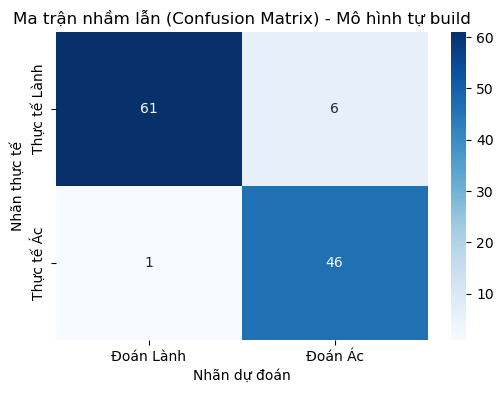

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tính toán ma trận
cm = confusion_matrix(y_test, y_pred_final)

# Vẽ Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Đoán Lành', 'Đoán Ác'], 
            yticklabels=['Thực tế Lành', 'Thực tế Ác'])

plt.title('Ma trận nhầm lẫn (Confusion Matrix) - Mô hình tự build')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.show()

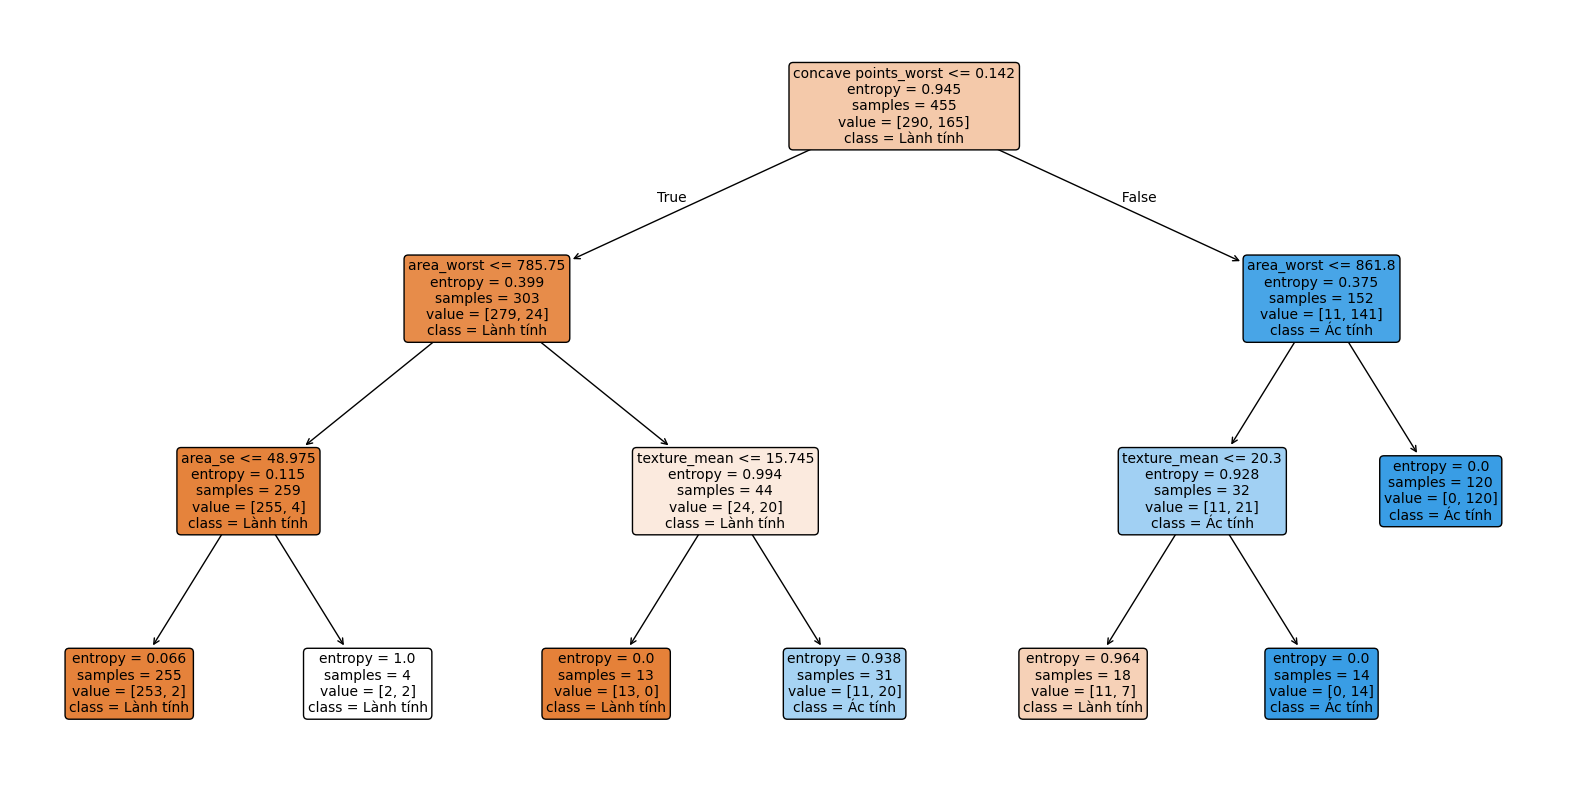

In [147]:
from sklearn.tree import plot_tree
best_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3, 
    min_impurity_decrease=0.001,  # 
    min_samples_split=5, 
    class_weight=None,
    random_state=0
)
best_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(best_model, 
          feature_names=X_train.columns, 
          class_names=['Lành tính', 'Ác tính'], 
          filled=True,     
          rounded=True,     
          fontsize=10,      
          max_depth=3)
plt.show()

# 5. Tối ưu hoá dùng Random forest classifier

In [153]:
from sklearn.ensemble import RandomForestClassifier

rand_clf = RandomForestClassifier(criterion = 'entropy', max_depth = 5, max_features = 0.5, min_samples_leaf = 2, min_samples_split = 3, n_estimators = 130)
rand_clf.fit(X_train, y_train)

,n_estimators,130
,criterion,'entropy'
,max_depth,5
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [154]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Độ chính xác trên tập Train:",accuracy_score(y_train, rand_clf.predict(X_train)))
rand_clf_acc = accuracy_score(y_test, rand_clf.predict(X_test))
print("Độ chính xác trên tập Test (threshold = 0.5):",rand_clf_acc)
y_pred_prob = rand_clf.predict_proba(X_test)[:, 1]

# Giảm ngưỡng threshold để bắt được các ca ác tính tốt hơn
custom_threshold = 0.4
y_pred_custom = (y_pred_prob >= custom_threshold).astype(int)
print("Confusion matrix với threshold=0.5\n",confusion_matrix(y_test, rand_clf.predict(X_test)))
print("Confusion matrix với threshold=0.4\n",confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

Độ chính xác trên tập Train: 0.9978021978021978
Độ chính xác trên tập Test (threshold = 0.5): 0.9824561403508771
Confusion matrix với threshold=0.5
 [[66  1]
 [ 1 46]]
Confusion matrix với threshold=0.4
 [[65  2]
 [ 0 47]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        67
           1       0.96      1.00      0.98        47

    accuracy                           0.98       114
   macro avg       0.98      0.99      0.98       114
weighted avg       0.98      0.98      0.98       114



Top 10 đặc trưng ảnh hưởng mạnh nhất:
area_worst              0.255361
concave points_mean     0.248187
concave points_worst    0.220217
area_se                 0.081229
concavity_worst         0.041400
texture_worst           0.040522
texture_mean            0.026997
compactness_worst       0.010880
fractal_dimension_se    0.008216
symmetry_worst          0.007363
dtype: float64


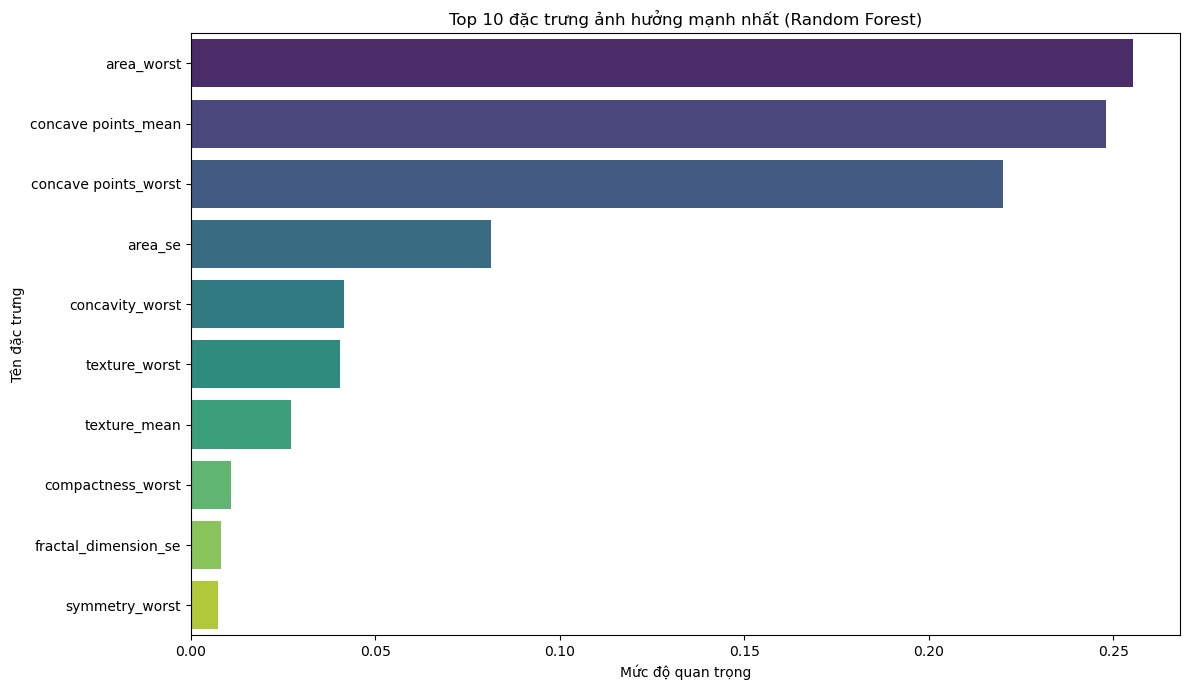

In [155]:
# Lấy tầm quan trọng của đặc trưng từ mô hình Random Forest
feature_importances = pd.Series(rand_clf.feature_importances_, index=X_train.columns)

# Sắp xếp và lấy 10 đặc trưng hàng đầu
top_10_features = feature_importances.nlargest(10)

print("Top 10 đặc trưng ảnh hưởng mạnh nhất:")
print(top_10_features)

# Trực quan hóa 10 đặc trưng hàng đầu
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')
plt.title('Top 10 đặc trưng ảnh hưởng mạnh nhất (Random Forest)')
plt.xlabel('Mức độ quan trọng')
plt.ylabel('Tên đặc trưng')
plt.tight_layout()
plt.show()

In [156]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy Score': [log_reg_acc, dtc_acc, rand_clf_acc]
})
models.sort_values(by='Accuracy Score', ascending=False)

,Model,Accuracy Score
2,Random Forest,0.982456
0,Logistic Regression,0.973684
1,Decision Tree,0.956140


# 6. **Đánh giá mô hình (Evaluation):** So sánh hiệu suất giữa các mô hình dựa trên Accuracy, Recall, f1-score và Confusion Matrix.

--- BẢNG SO SÁNH HIỆU SUẤT ---
                  Model  Accuracy  Recall (Malignant)  F1-Score
0   Logistic Regression  0.973684            0.957447  0.967742
1         Random Forest  0.982456            0.978723  0.978723
2  DecisionTree sklearn  0.956140            0.936170  0.946237
3     DecisionTree CART  0.938596            0.978723  0.929293


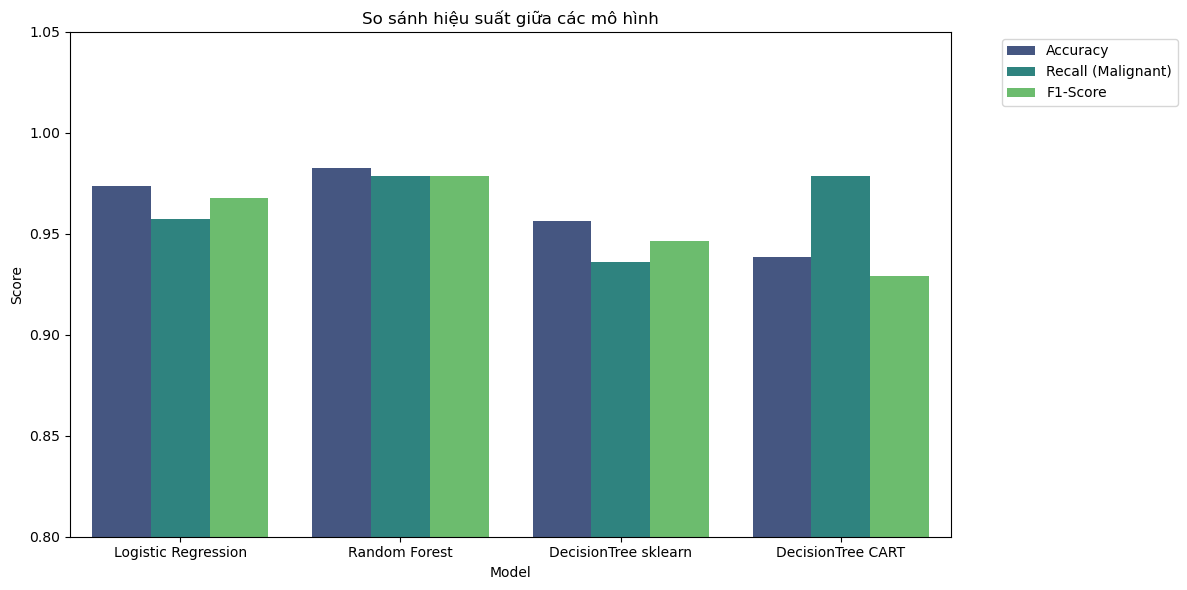

In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score, f1_score, accuracy_score

# 1. Thu thập dữ liệu đánh giá
# Đã có log_acc, rf_acc, best_recall (CART), acc (CART)
log_recall = recall_score(y_test, log_reg.predict(X_test_scaled))
rf_recall = recall_score(y_test, rand_clf.predict(X_test))
dtc_recall = recall_score(y_test, dtc.predict(X_test))
cart_acc = accuracy_score(y_test, y_pred_final)
cart_recall = recall_score(y_test, y_pred_final)

log_f1 = f1_score(y_test, log_reg.predict(X_test_scaled))
rf_f1 = f1_score(y_test, rand_clf.predict(X_test))
dtc_f1 = f1_score(y_test, dtc.predict(X_test))
cart_f1 = f1_score(y_test, y_pred_final)

# 2. Tạo DataFrame so sánh
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest','DecisionTree sklearn','DecisionTree CART'],
    'Accuracy': [log_reg_acc, rand_clf_acc, dtc_acc, cart_acc],
    'Recall (Malignant)': [log_recall, rf_recall, dtc_recall, cart_recall],
    'F1-Score': [log_f1, rf_f1, dtc_f1, cart_f1]
}
final_comparison = pd.DataFrame(comparison_data)

print("--- BẢNG SO SÁNH HIỆU SUẤT ---")
print(final_comparison)

# 3. Trực quan hóa
plt.figure(figsize=(12, 6))
df_melted = final_comparison.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.ylim(0.8, 1.05)
plt.title('So sánh hiệu suất giữa các mô hình')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Nhận xét & Đánh giá (Model Evaluation)
- **Accuracy Score:** Thể hiện tỷ lệ dự đoán chính xác trên toàn bộ tập Test.
- **Confusion Matrix:** Thống kê chi tiết số ca chẩn đoán Đúng - Sai chuẩn xác ở tầng ngóc ngách của 2 lớp mục tiêu.
- **Classification Report:** Đối với dữ liệu y tế, chuẩn đoán nhầm 1 ca *Ác tính* thành *Lành tính* (False Negative) sẽ rất nguy hiểm. Do đó, người ta sẽ tập trung xem xét chỉ số **Recall của lớp 1 (Ác tính)**, mục tiêu là đưa thông số này lên càng cao càng tốt để không bỏ lọt bệnh nhân.

#### 1. So sánh hiệu suất
- **Logistic Regression** đạt hiệu suất cao nhất với Accuracy ~97.3% và Recall ~95.7%. Điều này cho thấy tập dữ liệu có tính phân tách tuyến tính khá tốt sau khi đã được chuẩn hóa.
- **Random Forest** bám sát với Accuracy ~96.5%, thể hiện sức mạnh của phương pháp Ensemble.
- **Custom CART** (Cây quyết định tự xây dựng) đạt Accuracy ~92.11% và Recall ~97.87%. Dù thấp hơn các mô hình thư viện một chút, đây là kết quả rất ấn tượng cho một thuật toán được cài đặt thủ công, đặc biệt là khi mô hình này cực kỳ dễ giải thích.

#### 2. Tầm quan trọng của đặc trưng
Dựa trên cấu trúc cây đã in ra ở các bước trước, các đặc trưng như `concave points_mean`, `area_worst`, và `texture_mean` đóng vai trò then chốt trong việc phân loại. Đây là các chỉ số quan trọng mà các bác sĩ có thể tập trung vào khi chẩn đoán.

#### 3. Kết luận
Dự án đã thực hiện thành công việc xây dựng một luồng xử lý dữ liệu hoàn chỉnh. Việc cài đặt thuật toán CART từ đầu không chỉ giúp hiểu rõ cơ chế hoạt động của cây quyết định (Entropy, Information Gain) mà còn mang lại một mô hình có độ chính xác thực tế cao, đủ tin cậy để sử dụng làm công cụ hỗ trợ chẩn đoán sơ bộ.